In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("IMDB Dataset (1).csv")

In [3]:
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [4]:
df["sentiment"]=df["sentiment"].map({"positive":1,"negative":0})

In [5]:
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1
...,...,...
49995,I thought this movie did a down right good job...,1
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",0
49997,I am a Catholic taught in parochial elementary...,0
49998,I'm going to have to disagree with the previou...,0


In [6]:
x=df["review"]
y=df["sentiment"]

In [7]:
y

0        1
1        1
2        1
3        0
4        1
        ..
49995    1
49996    0
49997    0
49998    0
49999    0
Name: sentiment, Length: 50000, dtype: int64

In [8]:
x

0        One of the other reviewers has mentioned that ...
1        A wonderful little production. <br /><br />The...
2        I thought this was a wonderful way to spend ti...
3        Basically there's a family where a little boy ...
4        Petter Mattei's "Love in the Time of Money" is...
                               ...                        
49995    I thought this movie did a down right good job...
49996    Bad plot, bad dialogue, bad acting, idiotic di...
49997    I am a Catholic taught in parochial elementary...
49998    I'm going to have to disagree with the previou...
49999    No one expects the Star Trek movies to be high...
Name: review, Length: 50000, dtype: object

In [9]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.4)

In [10]:
x_train

18306    I borrowed (slightly modified) title from some...
49528    I was the Production Accountant on this movie,...
44745    By far this has to be one of the worst movies ...
46827    Obviously inspired by Se7en and sometimes even...
27531    This movie is of almost generation-defining im...
                               ...                        
11284    `Shadow Magic' recaptures the joy and amazemen...
44732    I found this movie to be quite enjoyable and f...
38158    Avoid this one! It is a terrible movie. So wha...
860      This production was quite a surprise for me. I...
15795    This is a decent movie. Although little bit sh...
Name: review, Length: 30000, dtype: object

In [11]:
y_train

18306    1
49528    1
44745    0
46827    1
27531    1
        ..
11284    1
44732    1
38158    0
860      1
15795    1
Name: sentiment, Length: 30000, dtype: int64

In [12]:
x_test

33553    I really liked this Summerslam due to the look...
9427     Not many television shows appeal to quite as m...
199      The film quickly gets to a major chase scene w...
12447    Jane Austen would definitely approve of this o...
39489    Expectations were somewhat high for me when I ...
                               ...                        
14324    A touching movie about a talented woman who st...
43453    I just came from seeing this movie and decided...
29499    Dolemite is one of the best movies featuring a...
42681    In the future, a disparate group of people asl...
42326    The Jazz Singer is one of a number of films ma...
Name: review, Length: 20000, dtype: object

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
vect=TfidfVectorizer(stop_words='english',max_features=2000)
x_train_vect=vect.fit_transform(x_train)
x_test_vect=vect.transform(x_test)

In [14]:
x_train_vect

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1712240 stored elements and shape (30000, 2000)>

In [15]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x_train_vect,y_train)

LogisticRegression()

In [16]:
from sklearn.naive_bayes import MultinomialNB
mn=MultinomialNB()
mn.fit(x_train_vect,y_train)

MultinomialNB()

In [18]:
lr_pred=lr.predict(x_test_vect)


In [19]:
mn_pred=mn.predict(x_test_vect)

In [22]:
from sklearn.metrics import confusion_matrix,accuracy_score
print("Logistic_accuracy:",accuracy_score(lr_pred,y_test))
print("Confusion_metrics_lr:",confusion_matrix(lr_pred,y_test))

Logistic_accuracy: 0.8755
Confusion_metrics_lr: [[8580 1081]
 [1409 8930]]


In [23]:
from sklearn.metrics import confusion_matrix,accuracy_score
print("Multi_accuracy:",accuracy_score(mn_pred,y_test))
print("Multi_metrics_lr:",confusion_matrix(mn_pred,y_test))

Multi_accuracy: 0.84435
Multi_metrics_lr: [[8292 1416]
 [1697 8595]]


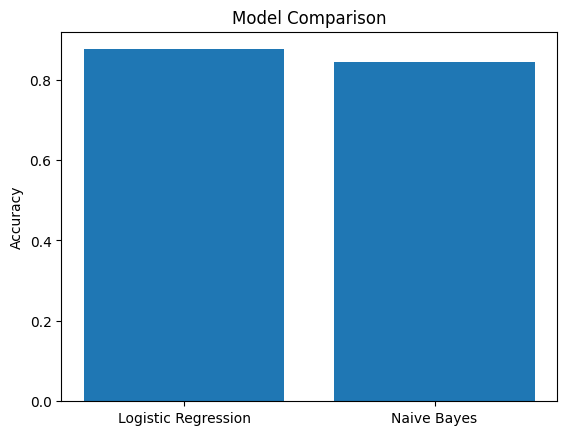

In [25]:
models = ['Logistic Regression', 'Naive Bayes']
accuracies = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, mn_pred)
]

plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

In [29]:
def predict_sentiment(text):
    text_vec = vect.transform([text])
    prediction = lr.predict(text_vec)
    
    if prediction[0] == 1:
        return "Positive "
    else:
        return "Negative "

# Test
print(predict_sentiment("This product is amazing!"))
print(predict_sentiment("Worst experience ever"))

Positive 
Negative 
